Numpy array vs Python list

In [2]:
# speed
# list
a = [i for i in range(10000000)]
b = [i for i in range(10000000, 20000000)]

c = []

import time

start = time.time()
for i in range(len(a)):
    c.append(a[i] + b[i])
print(time.time() - start)

4.277064561843872


In [3]:
# numpy
import numpy as np
a = np.arange(10000000)
b = np.arange(10000000, 20000000)

start = time.time()
c = a + b
print(time.time()-start)

0.3265976905822754


In [4]:
7.09/0.51

13.901960784313726

In [5]:
# memory
a = [i for i in range(10000000)]
import sys

sys.getsizeof(a)

89095160

In [6]:
# a = np.arange(10000000)
# a = np.arange(10000000, dtype=np.int32)
# a = np.arange(10000000, dtype=np.int16)
# a = np.arange(10000000, dtype=np.int8)
# sys.getsizeof(a)
a = np.arange(10000000, dtype=np.int8)

print(a[-10:])

[118 119 120 121 122 123 124 125 126 127]


In [7]:
# convenience
# numpy is better than python list
# numpy takes less time, space and memory compared to python list
# more convenient to work with numpy

Advanced Indexing

In [8]:
# Fancy indexing
a = np.arange(24).reshape(6, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [9]:
# a[[0, 2, 3]]
# a[[0, 2, 3, 5]]
a[:,[0,2,3]]

array([[ 0,  2,  3],
       [ 4,  6,  7],
       [ 8, 10, 11],
       [12, 14, 15],
       [16, 18, 19],
       [20, 22, 23]])

In [10]:
# Boolean indexing
# indexing based on condition
a = np.random.randint(1, 100, 24).reshape(6, 4)
a

array([[32, 21, 61, 56],
       [73, 77,  5, 65],
       [74, 91, 47, 57],
       [53, 21, 99, 60],
       [ 1, 35, 78,  7],
       [16, 80, 37, 27]], dtype=int32)

In [11]:
# find all the numbers greater than 50
# a > 50
a[a > 50]   # give all no. greater than 50

array([61, 56, 73, 77, 65, 74, 91, 57, 53, 99, 60, 78, 80], dtype=int32)

In [12]:
# find out even numbers
# a % 2 == 0
a[a % 2 == 0]

array([32, 56, 74, 60, 78, 16, 80], dtype=int32)

In [13]:
# greater then 50 and even
# (a > 50) & (a % 2 == 0)
a[(a > 50) & (a % 2 == 0)]

array([56, 74, 60, 78, 80], dtype=int32)

In [14]:
# all numbers divisible by 7
# a[a % 7 == 0]
a[~(a % 7 == 0)]

array([32, 61, 73,  5, 65, 74, 47, 57, 53, 99, 60,  1, 78, 16, 80, 37, 27],
      dtype=int32)

Broadcasting

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.
The smaller array is "broadcast" across the larger array so that they have compatible shapes.

In [15]:
# same shape
a = np.arange(6).reshape(2, 3)
b = np.arange(6,12).reshape(2, 3)

print(a)
print(b)

print(a+b)

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]
[[ 6  8 10]
 [12 14 16]]


In [16]:
# diff shape
a = np.arange(6).reshape(2, 3)
b = np.arange(3).reshape(1, 3)

print(a)
print(b)

print(a+b)

[[0 1 2]
 [3 4 5]]
[[0 1 2]]
[[0 2 4]
 [3 5 7]]


#### Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**<br>
- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.<br>

**2. Make each dimension of the two arrays the same size.**<br>
- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

![alt text](image.png)

In [18]:
a = np.arange(12).reshape(4, 3)
b = np.arange(3)

print(a)
print(b)

print(a+b)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[0 1 2]
[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [ ]:
a = np.arange(12).reshape(3, 4)
b = np.arange(3)

print(a)
print(b)

# print(a+b)        # error

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2]


ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [20]:
a = np.arange(3).reshape(1, 3)
b = np.arange(3).reshape(3, 1)

print(a)
print(b)

print(a+b)

[[0 1 2]]
[[0]
 [1]
 [2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [21]:
a = np.arange(3).reshape(1, 3)
b = np.arange(4).reshape(4, 1)

print(a)
print(b)

print(a+b)

[[0 1 2]]
[[0]
 [1]
 [2]
 [3]]
[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [22]:
a = np.array([1])
# shape -> (1, 1)

b = np.arange(4).reshape(2,2)
# shape -> (2, 2)

print(a)
print(b)

print(a+b)

[1]
[[0 1]
 [2 3]]
[[1 2]
 [3 4]]


In [ ]:
a = np.arange(12).reshape(3, 4)
b = np.arange(12).reshape(4, 3)

print(a)
print(b)

# print(a+b)   # error

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


ValueError: operands could not be broadcast together with shapes (3,4) (4,3) 

In [ ]:
a = np.arange(16).reshape(4, 4)
b = np.arange(4).reshape(2, 2)

print(a)
print(b)

# print(a+b)            # error

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[0 1]
 [2 3]]


ValueError: operands could not be broadcast together with shapes (4,4) (2,2) 

Working with mathematical formulas

In [26]:
# sigmoid
# calculating sigmoid of 10 values in an array
def sigmoid(array):
    return 1/(1+np.exp(-(array)))

a = np.arange(10)

sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661])

In [28]:
# mean squared error

actual = np.random.randint(1, 50, 25)
predicted = np.random.randint(1, 50, 25)

actual

array([20, 14, 18, 23, 15,  7,  6, 32, 46, 10,  1, 37, 40, 46, 14, 14, 47,
       20, 32,  2, 46, 21, 38, 25, 23], dtype=int32)

In [29]:
predicted

array([18,  9, 21, 38, 40, 46, 47, 48, 23,  3, 45, 32, 30, 11, 43,  4,  6,
       41, 42, 44, 19, 39, 38,  9,  2], dtype=int32)

In [31]:
def mse(actual, predicted):
    return np.mean((actual - predicted)**2)

mse(actual, predicted)

np.float64(595.48)

In [ ]:
# binary cross entropy
y_true = np.array([1,0,1,1,0,1,0,1,0,1])
y_pred = np.array([0.95,0.10,0.82,0.76,0.20,0.91,0.05,0.70,0.35,0.88])

bce = -np.mean(
    y_true * np.log(y_pred) +
    (1 - y_true) * np.log(1 - y_pred)
)

bce

np.float64(0.19135803511850485)

Working with missing values

In [43]:
# working with missing values -> np.nan
a = np.array([1, np.nan, 3, 4, np.nan, 6])
a

array([ 1., nan,  3.,  4., nan,  6.])

In [45]:
# np.isnan(a)
a[~np.isnan(a)]

array([1., 3., 4., 6.])

Plotting Graphs

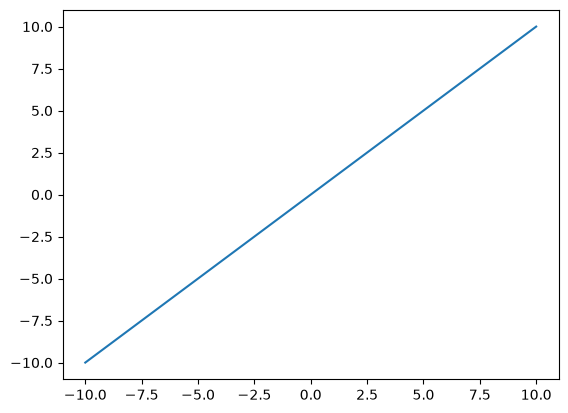

In [49]:
# plotting a 2D plot
# x = y
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = x

plt.plot(x, y)

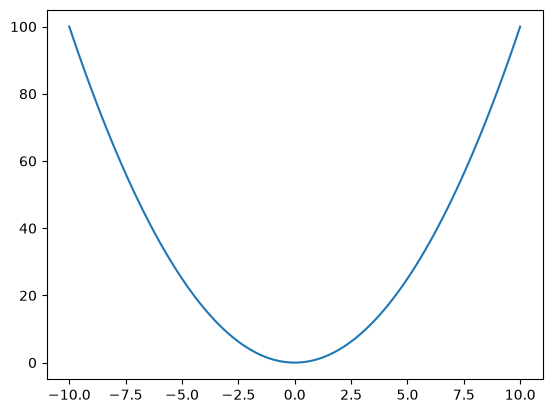

In [50]:
# y = x^2
# parabola

x = np.linspace(-10, 10, 100)
y = x**2

plt.plot(x, y)


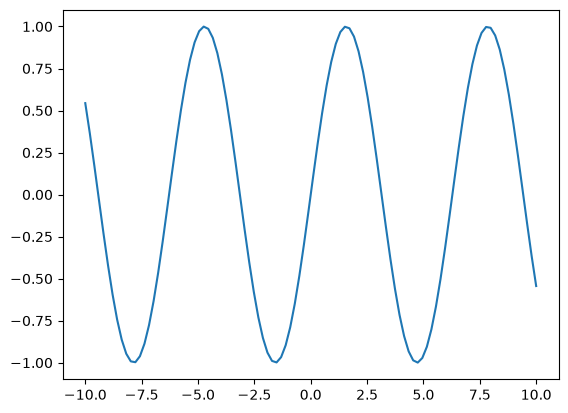

In [51]:
# y = sin(x)
x = np.linspace(-10, 10, 100)
y = np.sin(x)

plt.plot(x, y)

C:\Users\hp\AppData\Local\Temp\ipykernel_65844\2564014901.py:3: RuntimeWarning: invalid value encountered in log
  y = x * np.log(x)


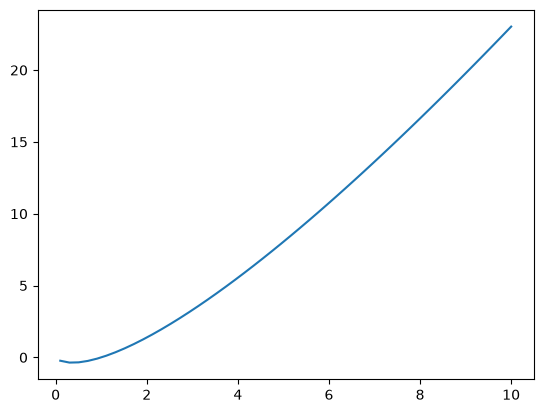

In [52]:
# y = xlog(x)
x = np.linspace(-10,10,100)
y = x * np.log(x)

plt.plot(x,y)

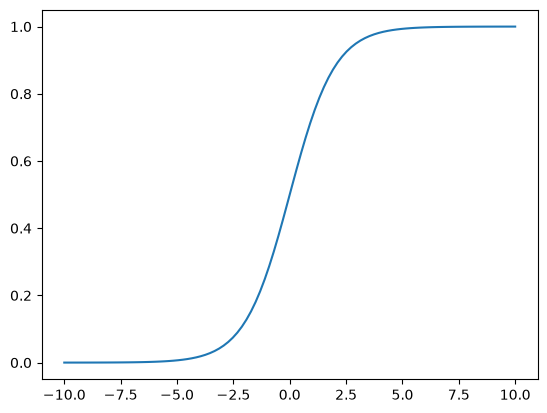

In [53]:
# sigmoid
x = np.linspace(-10, 10, 100)
y = 1/(1+np.exp(-x))

plt.plot(x, y)